# EZIE Mag - Daily Notebook

**Project:** EZIE Mag Summer Research Project

This notebook is **Stage 2** of the EZIE Mag pipeline: it loads one
day's already-cleaned data from `data/processed/` and produces
labeled time-series plots for review.

This notebook does **no** cleaning, gap-filling, or feature
engineering of its own - all of that happens once, upstream, in the
Processing Notebook. If the day you want to look at hasn't been
processed yet, run it through the Processing Notebook first.

**Plots produced:**
- Bx, By, Bz (raw components)
- B_total (total field magnitude)
- Bh (horizontal field magnitude) and D (declination)
- Central time view
- Comparison with USGS reference observatories (FRD, Boulder)

## 1. Setup

Import required libraries and the project's helper module.

In [32]:
# --- Path setup ---
# This notebook lives in notebooks/, but ezie_utils.py and the data/
# folder live one level up, at the project root.
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

import ezie_utils

## 2. Settings

Enter the date (YYYYMMDD) to load. This must be a day that's already
been processed - i.e. a file already exists at
`data/processed/eziemag_<date>_processed.csv`.

In [33]:
PROCESSED_DIR = "../data/processed"

date_str = input("Enter date (YYYYMMDD): ").strip()

# Basic validation - matches the same checks used in the Processing
# Notebook, so a malformed date is caught here too rather than
# producing a confusing file-not-found error.
if not (date_str.isdigit() and len(date_str) == 8):
    raise ValueError(
        f"Invalid date '{date_str}'. Please enter exactly 8 digits in YYYYMMDD format (e.g. 20260609)."
    )

processed_path = os.path.join(PROCESSED_DIR, f"eziemag_{date_str}_processed.csv")

if not os.path.exists(processed_path):
    raise FileNotFoundError(
        f"No processed file found for {date_str} at {processed_path}.\n"
        f"Run the Processing Notebook for this date first."
    )

print("Loading:", processed_path)

Enter date (YYYYMMDD):  20260610


Loading: ../data/processed/eziemag_20260610_processed.csv


## 3. Load Data

Load the processed CSV directly - already gap-filled, with B_total,
Bh, and D already computed.

In [34]:
df = pd.read_csv(processed_path, index_col="timeString", parse_dates=True)

print("Shape:", df.shape)
print("Time range:", df.index.min(), "to", df.index.max())

# Which device is this data from
fingerprints = df["fingerprint"].dropna().unique()
for fp in fingerprints:
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    print(f"Device: {fp} ({name})")

df.head()

Shape: (1440, 26)
Time range: 2026-06-10 00:00:00+00:00 to 2026-06-10 23:59:00+00:00
Device: AAAAAIzs1uUA (Zane (Keller, TX))


,tval,intt,nsamp,stid,fingerprint,lat,lon,alt,tres,ctemp,...,Ax,Ay,Az,Gx,Gy,Gz,imu_ctemp,B_total,Bh,D
timeString,,,,,,,,,,,,,,,,,,,,,
2026-06-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-10 00:01:00+00:00,1.781050e+09,60.0,1998.0,"""eziemag""",AAAAAIzs1uUA,32.952033,-97.255747,220.1,3.0,24.2500,...,0.157926,-0.084945,9.818948,-0.003512,-0.003818,-0.005192,24.109375,39874.308701,18010.463928,3.898981
2026-06-10 00:02:00+00:00,1.781050e+09,60.0,2035.0,"""eziemag""",AAAAAIzs1uUA,32.952033,-97.255747,220.1,3.0,24.3125,...,0.155533,-0.101695,9.817751,-0.003818,-0.003818,-0.005651,24.078125,39864.184932,18011.068537,3.911497
2026-06-10 00:03:00+00:00,1.781050e+09,60.0,2030.0,"""eziemag""",AAAAAIzs1uUA,32.952055,-97.255745,220.2,3.0,24.3125,...,0.161516,-0.086740,9.815957,-0.003818,-0.003818,-0.005956,24.062500,39857.277092,18008.159787,3.924406
2026-06-10 00:04:00+00:00,1.781050e+09,60.0,2037.0,"""eziemag""",AAAAAIzs1uUA,32.952055,-97.255745,220.2,3.0,24.2500,...,0.150150,-0.092722,9.827322,-0.003665,-0.004581,-0.005498,24.085938,39862.229311,18009.846550,3.890200


## 4. Daily Plots: Bx, By, Bz

Time-series plots of the three raw magnetic field components, in
sensor units (nT, uncalibrated). The x-axis uses real UTC timestamps,
so any data gaps (e.g. from power outages) appear naturally as breaks
in the line rather than misleading straight-line connections.

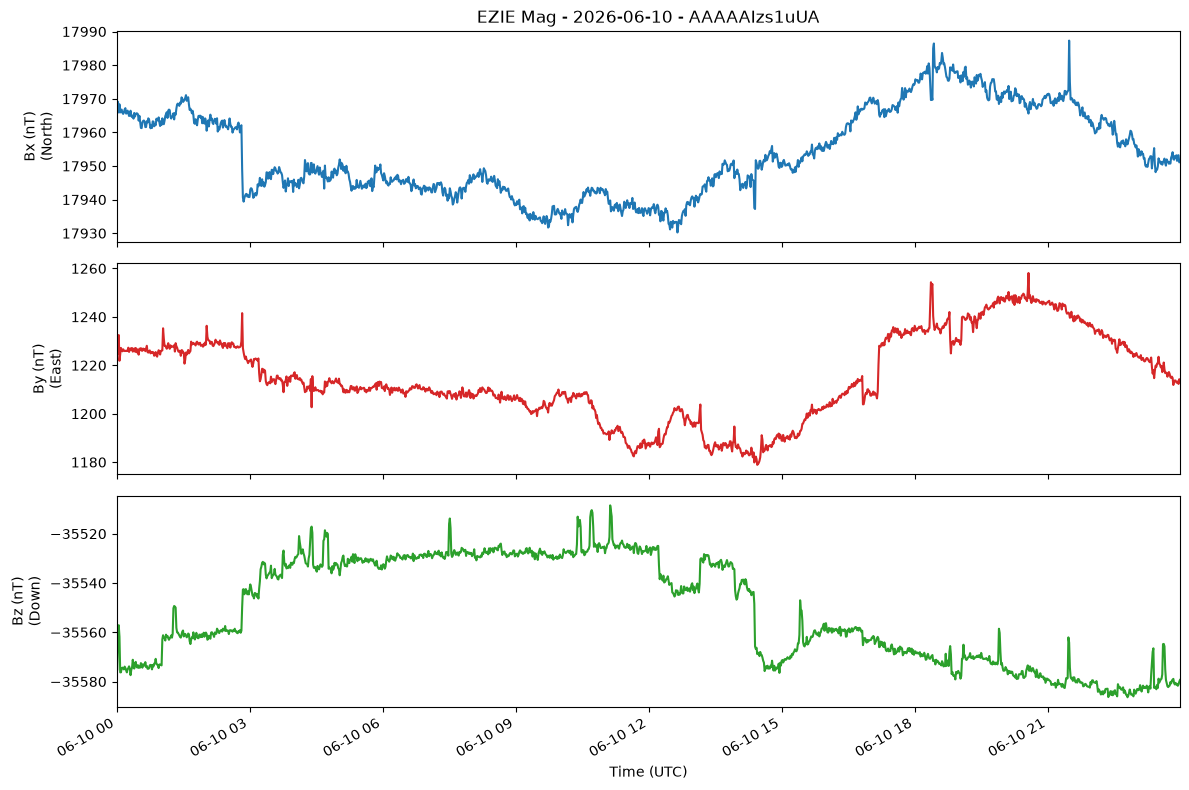

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

fingerprint = df["fingerprint"].dropna().unique()[0]

axes[0].plot(df.index, df["Bx"], color="tab:blue")
axes[0].set_ylabel("Bx (nT)\n(North)")
axes[0].set_title(f"EZIE Mag - {df.index[0].date()} - {fingerprint}")
axes[0].set_xlim(df.index.min(), df.index.max())

axes[1].plot(df.index, df["By"], color="tab:red")
axes[1].set_ylabel("By (nT)\n(East)")
axes[1].set_xlim(df.index.min(), df.index.max())

axes[2].plot(df.index, df["Bz"], color="tab:green")
axes[2].set_ylabel("Bz (nT)\n(Down)")
axes[2].set_xlabel("Time (UTC)")
axes[2].set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Total Field Magnitude (B_total)

$$B_{total} = \sqrt{B_x^2 + B_y^2 + B_z^2}$$

Rotation-independent overall field strength, comparable to an
observatory's reported F value.

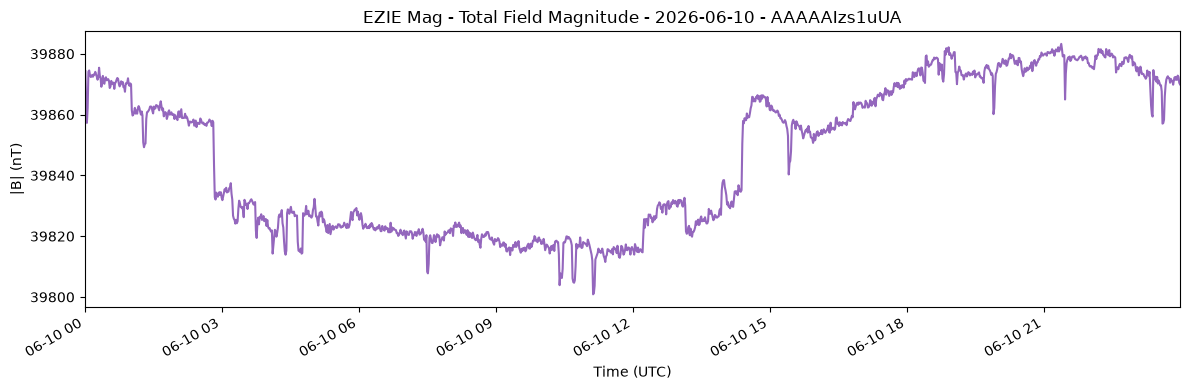

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["B_total"], color="tab:purple")
ax.set_ylabel("|B| (nT)")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Mag - Total Field Magnitude - {df.index[0].date()} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Horizontal Field Magnitude (Bh)

$$B_h = \sqrt{B_x^2 + B_y^2}$$

Bh isolates the horizontal component of the field (North + East,
excluding Down). This is the standard geomagnetic "H" quantity
reported by observatories, useful because it isolates horizontal
variation (often driven by ionospheric/magnetospheric currents) from
the typically much steadier vertical component. Still in raw sensor
units until affine calibration is applied.

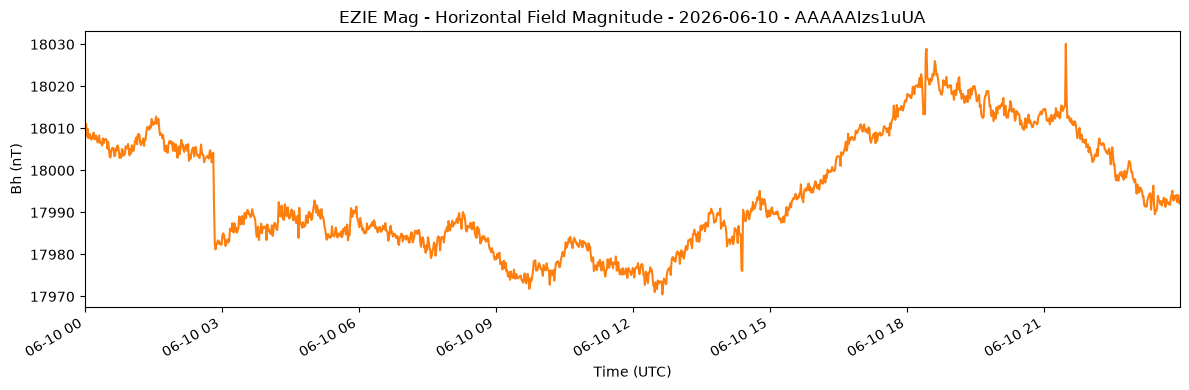

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["Bh"], color="tab:orange")
ax.set_ylabel("Bh (nT)")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Mag - Horizontal Field Magnitude - {df.index[0].date()} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Declination (D)

$$D = \arctan2(B_y, B_x)$$

Declination is the angle, in degrees, of the horizontal field
relative to the sensor's +X axis. This is the standard geomagnetic
"D" quantity reported by observatories. Computed using `atan2` rather
than plain `arctan(By/Bx)`, since `atan2` correctly handles all four
quadrants. Still relative to the sensor's own (possibly rotated) +X
axis until affine calibration is applied - not necessarily true
magnetic North.

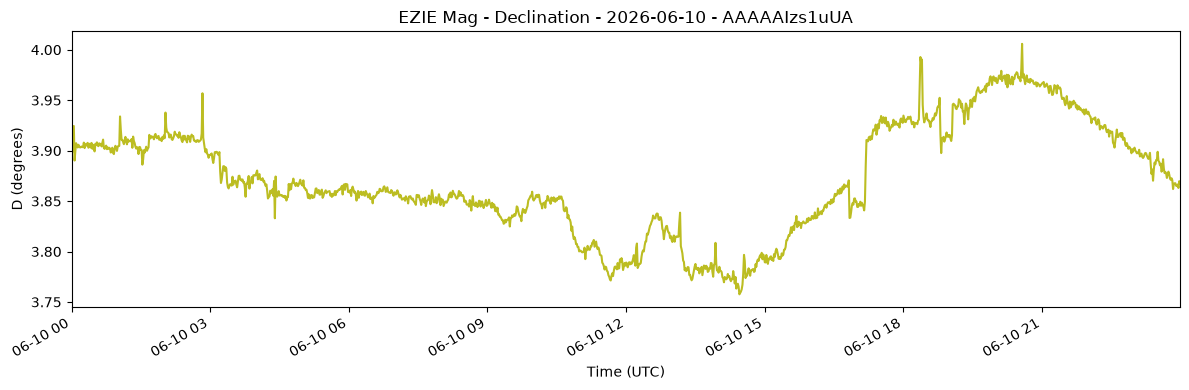

In [38]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["D"], color="tab:olive")
ax.set_ylabel("D (degrees)")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Mag - Declination - {df.index[0].date()} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Comparison with USGS Observatories (FRD + Boulder)

Overlays EZIE data with public reference data from the USGS
Fredericksburg (FRD) and Boulder (BOU) geomagnetic observatories for
the same day.

Each dataset is **z-score normalized** before plotting:

$$z = \frac{value - \text{mean}}{\text{std}}$$

This removes both the absolute offset and the amplitude differences
between raw EZIE sensor units and calibrated observatory values,
putting everything on a common unitless scale where 0 = that
dataset's average and ±1 = one standard deviation from it. This
forces all lines onto the same visual scale regardless of their
original nT ranges, making it much easier to compare **shape** - if
a magnetic disturbance shows up in both EZIE and the observatories
at the same time, the normalized lines should move together even if
the raw amplitudes were very different.

**Known observation:** the North (Bx vs X) component tracks the
observatory data well, but the East (By vs Y) component appears
**inverted** - when observatory Y goes up, EZIE By goes down, and
vice versa. This is consistent with the sensor's physical mounting
having a flipped axis relative to true geographic East, which is
exactly what the affine calibration (rotation matrix A) is designed
to correct. This inversion is **not** corrected here - it will be
resolved when calibration is implemented.

Requires the `requests` library (`pip install requests` if not
installed).

Fetching FRD...
  FRD: 1441 rows loaded
Fetching BOU...
  BOU: 1441 rows loaded


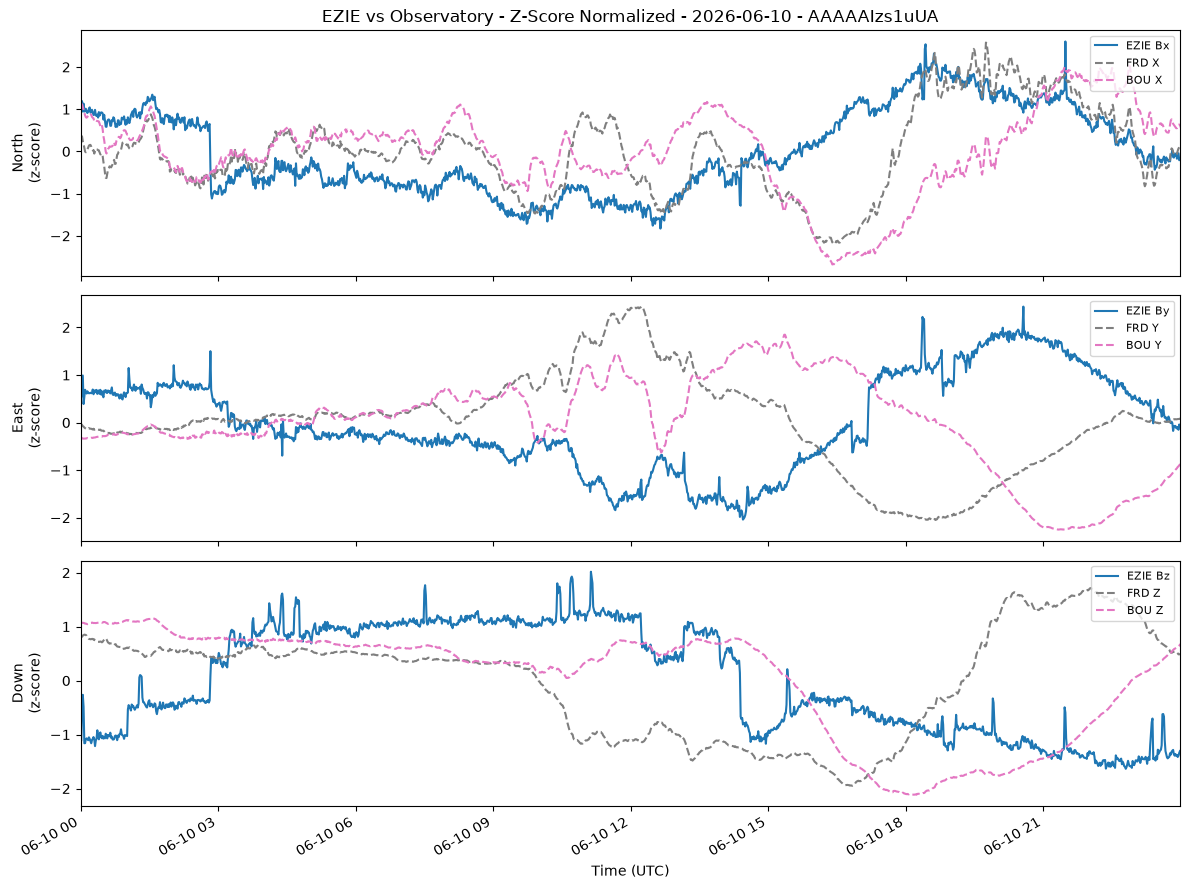

In [41]:
import requests

# --- Fetch reference data from both observatories ---
day_start = df.index.min()
if day_start.tz is None:
    day_start = pd.Timestamp(day_start).tz_localize("UTC")

day_end = day_start.floor("D") + pd.Timedelta(days=1)

observatories = {
    "FRD": "tab:gray",
    "BOU": "tab:pink"
}

obs_dfs = {}

for obs_id in observatories:
    url = (
        "https://geomag.usgs.gov/ws/data/"
        f"?id={obs_id}"
        f"&starttime={day_start.floor('D').strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&elements=X,Y,Z,F"
        f"&sampling_period=60"
        f"&format=json"
    )

    print(f"Fetching {obs_id}...")

    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        times = pd.to_datetime(data["times"])
        obs_df = pd.DataFrame(index=times)
        for element in data["values"]:
            name = element["metadata"]["element"]
            obs_df[name] = element["values"]

        obs_dfs[obs_id] = obs_df
        print(f"  {obs_id}: {obs_df.shape[0]} rows loaded")

    except Exception as e:
        print(f"  {obs_id}: failed to fetch ({e})")

# --- Overlay plots: z-score normalized on a shared axis ---
# Z-score normalization: z = (value - mean) / std
# This removes both the absolute offset AND amplitude differences
# between datasets, putting everything on a common unitless scale.
# A z-score of +2 means "2 standard deviations above this dataset's
# own average" regardless of whether the original data was 50 nT or
# 5000 nT - making shape comparison much clearer.
components = [
    ("Bx", "X", "North"),
    ("By", "Y", "East"),
    ("Bz", "Z", "Down")
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, (ezie_col, obs_col, label) in zip(axes, components):
    # EZIE z-score
    ezie_mean = df[ezie_col].mean()
    ezie_std = df[ezie_col].std()
    ezie_z = (df[ezie_col] - ezie_mean) / ezie_std
    ax.plot(df.index, ezie_z, color="tab:blue", label=f"EZIE {ezie_col}")

    # Observatory z-scores
    for obs_id, color in observatories.items():
        if obs_id in obs_dfs:
            obs_mean = obs_dfs[obs_id][obs_col].mean()
            obs_std = obs_dfs[obs_id][obs_col].std()
            obs_z = (obs_dfs[obs_id][obs_col] - obs_mean) / obs_std
            ax.plot(
                obs_dfs[obs_id].index, obs_z,
                color=color, linestyle="--", label=f"{obs_id} {obs_col}"
            )

    ax.set_ylabel(f"{label}\n(z-score)")
    ax.set_xlim(df.index.min(), df.index.max())
    ax.legend(loc="upper right", fontsize=8)

axes[0].set_title(f"EZIE vs Observatory - Z-Score Normalized - {df.index[0].date()} - {fingerprint}")
axes[-1].set_xlabel("Time (UTC)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Total Field and Horizontal Field - Observatory Comparison

Z-score normalized comparison of EZIE's derived fields against the
corresponding observatory quantities:

- **B_total** vs observatory **F** (total field magnitude)
- **Bh** vs observatory **H** (horizontal field magnitude)

Same normalization as Section 8 - each dataset is independently
z-scored so shape/trend can be compared directly regardless of
absolute scale differences.

Fetching H, F for FRD...
  FRD: 1441 rows loaded
Fetching H, F for BOU...
  BOU: 1441 rows loaded


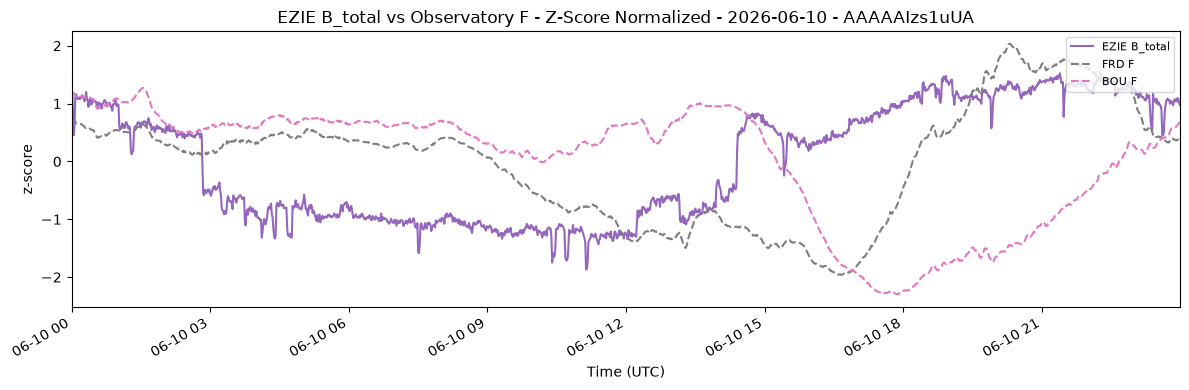

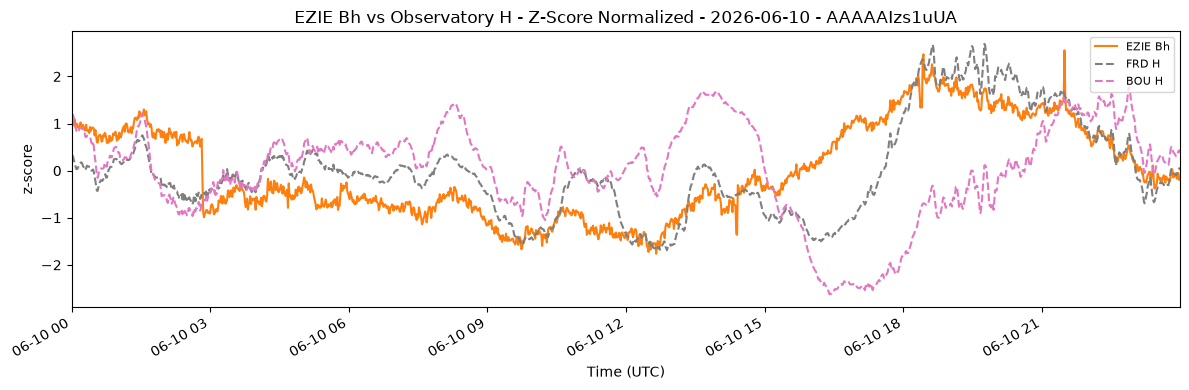

In [42]:
# --- Fetch H element from observatories ---
# Section 8 fetched X, Y, Z, F — we need H as well for the Bh
# comparison. Re-fetch with H included.
obs_dfs_hf = {}

day_start = df.index.min()
if day_start.tz is None:
    day_start = pd.Timestamp(day_start).tz_localize("UTC")

day_end = day_start.floor("D") + pd.Timedelta(days=1)

for obs_id in observatories:
    url = (
        "https://geomag.usgs.gov/ws/data/"
        f"?id={obs_id}"
        f"&starttime={day_start.floor('D').strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&elements=H,F"
        f"&sampling_period=60"
        f"&format=json"
    )

    print(f"Fetching H, F for {obs_id}...")

    try:
        for attempt in range(3):
            try:
                response = requests.get(url, timeout=60)
                response.raise_for_status()
                data = response.json()
                break
            except Exception:
                if attempt < 2:
                    print(f"  {obs_id}: retrying ({attempt + 1}/3)...")
                else:
                    raise

        times = pd.to_datetime(data["times"])
        obs_df = pd.DataFrame(index=times)
        for element in data["values"]:
            name = element["metadata"]["element"]
            obs_df[name] = element["values"]

        obs_dfs_hf[obs_id] = obs_df
        print(f"  {obs_id}: {obs_df.shape[0]} rows loaded")

    except Exception as e:
        print(f"  {obs_id}: failed after 3 attempts ({e})")

# --- B_total vs observatory F ---
fig, ax = plt.subplots(figsize=(12, 4))

ezie_mean = df["B_total"].mean()
ezie_std = df["B_total"].std()
ezie_z = (df["B_total"] - ezie_mean) / ezie_std
ax.plot(df.index, ezie_z, color="tab:purple", label="EZIE B_total")

for obs_id, color in observatories.items():
    if obs_id in obs_dfs_hf and "F" in obs_dfs_hf[obs_id].columns:
        obs_mean = obs_dfs_hf[obs_id]["F"].mean()
        obs_std = obs_dfs_hf[obs_id]["F"].std()
        obs_z = (obs_dfs_hf[obs_id]["F"] - obs_mean) / obs_std
        ax.plot(
            obs_dfs_hf[obs_id].index, obs_z,
            color=color, linestyle="--", label=f"{obs_id} F"
        )

ax.set_ylabel("z-score")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE B_total vs Observatory F - Z-Score Normalized - {df.index[0].date()} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Bh vs observatory H ---
fig, ax = plt.subplots(figsize=(12, 4))

ezie_mean = df["Bh"].mean()
ezie_std = df["Bh"].std()
ezie_z = (df["Bh"] - ezie_mean) / ezie_std
ax.plot(df.index, ezie_z, color="tab:orange", label="EZIE Bh")

for obs_id, color in observatories.items():
    if obs_id in obs_dfs_hf and "H" in obs_dfs_hf[obs_id].columns:
        obs_mean = obs_dfs_hf[obs_id]["H"].mean()
        obs_std = obs_dfs_hf[obs_id]["H"].std()
        obs_z = (obs_dfs_hf[obs_id]["H"] - obs_mean) / obs_std
        ax.plot(
            obs_dfs_hf[obs_id].index, obs_z,
            color=color, linestyle="--", label=f"{obs_id} H"
        )

ax.set_ylabel("z-score")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Bh vs Observatory H - Z-Score Normalized - {df.index[0].date()} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 10. Summary Statistics

Quick overview of the day's magnetic field data - useful for weekly
reports and spotting anomalies at a glance.

In [21]:
df[["Bx", "By", "Bz", "B_total", "Bh", "D"]].describe()

,Bx,By,Bz,B_total,Bh,D
count,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000
mean,17939.107748,1221.746223,-35554.612919,39842.629837,17980.670288,3.896139
std,9.865968,15.512317,13.245793,10.524595,9.171175,0.050768
min,17904.667875,1196.693413,-35577.656343,39815.152460,17947.328888,3.813680
25%,17932.223409,1211.301601,-35566.828414,39834.832150,17974.994193,3.862217
50%,17938.461610,1217.931530,-35554.185201,39843.422705,17979.596380,3.885558
75%,17942.891887,1236.175552,-35545.076069,39852.525587,17983.941073,3.943477
max,17976.724871,1256.466675,-35523.642625,39860.950858,18016.678302,4.008345
